In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('bicycle.csv')
df.head()

,가입일자,사용자코드,성별,연령대코드,신규가입자수
0,2025-12-31,회원-내국인,M,기타,26
1,2025-12-31,회원-내국인,M,70대이상,4
2,2025-12-31,회원-내국인,M,60대,7
3,2025-12-31,회원-내국인,M,50대,19
4,2025-12-31,회원-내국인,M,40대,16


In [9]:
df['가입일자'] = pd.to_datetime(df['가입일자'])
df.dtypes

가입일자      datetime64[us]
사용자코드                str
성별                   str
연령대코드                str
신규가입자수             int64
dtype: object

In [18]:
df_2024 = df[df['가입일자'].dt.year>=2021]
monthly_sum = (df_2024.groupby(df['가입일자'].dt.strftime('%Y-%m'))['신규가입자수']
                 .sum()
                 .reset_index()
               )
monthly_sum

,가입일자,신규가입자수
0,2021-01,17738
1,2021-02,44796
2,2021-03,69606
3,2021-04,93907
4,2021-05,80653
5,2021-06,71941
6,2021-07,55969
7,2021-08,60262
8,2021-09,81525
9,2021-10,56614


     년도   신규가입자수
0  2017   384288
1  2018   589528
2  2019   806453
3  2020  1207286
4  2021   684298
5  2022   336871
6  2025   385308


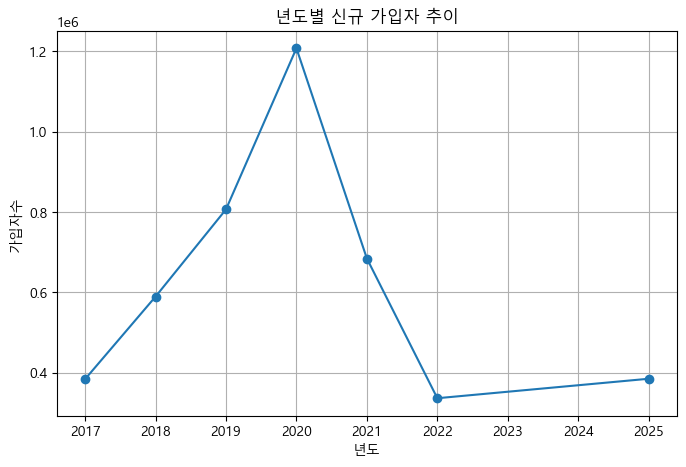

In [21]:
import matplotlib.pyplot as plt

# 연도 컬럼 생성
df['년도'] = df['가입일자'].dt.year

# 연도별 가입자수 합계
yearly_sum = (
    df.groupby('년도')['신규가입자수']
      .sum()
      .reset_index()
)

print(yearly_sum)

# 그래프 출력
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_sum['년도'],
    yearly_sum['신규가입자수'],
    marker='o'
)

plt.title('년도별 신규 가입자 추이')
plt.xlabel('년도')
plt.ylabel('가입자수')

plt.grid(True)

plt.show()